**SEED**

In [1]:
import tensorflow as tf
import numpy as np
import random

seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)
random.seed(seed)

In [2]:
import os

os.environ['KAGGLE_USERNAME'] = 'suhaniojha3008'
os.environ['KAGGLE_KEY'] = 'KGAT_2d0224d8e1d6c3aedf4778c3d13365e1'

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/best_model.keras",
    monitor='val_accuracy',
    save_best_only=True
)

**Download Dataset**

In [7]:
!kaggle datasets download -d paultimothymooney/breast-histopathology-images
!unzip breast-histopathology-images.zip

Streaming output truncated to the last 5000 lines.
  inflating: IDC_regular_ps50_idx5/9346/0/9346_idx5_x2351_y1551_class0.png  
  inflating: IDC_regular_ps50_idx5/9346/0/9346_idx5_x2351_y1601_class0.png  
  inflating: IDC_regular_ps50_idx5/9346/0/9346_idx5_x2351_y1651_class0.png  
  inflating: IDC_regular_ps50_idx5/9346/0/9346_idx5_x2351_y1701_class0.png  
  inflating: IDC_regular_ps50_idx5/9346/0/9346_idx5_x2351_y1751_class0.png  
  inflating: IDC_regular_ps50_idx5/9346/0/9346_idx5_x2351_y1801_class0.png  
  inflating: IDC_regular_ps50_idx5/9346/0/9346_idx5_x2351_y1851_class0.png  
  inflating: IDC_regular_ps50_idx5/9346/0/9346_idx5_x2351_y1901_class0.png  
  inflating: IDC_regular_ps50_idx5/9346/0/9346_idx5_x2351_y1951_class0.png  
  inflating: IDC_regular_ps50_idx5/9346/0/9346_idx5_x2351_y2001_class0.png  
  inflating: IDC_regular_ps50_idx5/9346/0/9346_idx5_x2351_y2251_class0.png  
  inflating: IDC_regular_ps50_idx5/9346/0/9346_idx5_x2351_y2301_class0.png  
  inflating: IDC_regular_

**Prepare dataset**

**Create BALANCED DATASET**

In [ ]:
import os
import shutil

source_dir = "/content/IDC_regular_ps50_idx5"
target_dir = "/content/dataset"

# reset
if os.path.exists(target_dir):
    shutil.rmtree(target_dir)

os.makedirs(os.path.join(target_dir, "class0"))
os.makedirs(os.path.join(target_dir, "class1"))

count0, count1 = 0, 0
LIMIT = 4000   # increase data (better accuracy)

for root, dirs, files in os.walk(source_dir):
    for file in files:
        if file.endswith(".png"):
            path = os.path.join(root, file)

            if root.endswith("0") and count0 < LIMIT:
                shutil.copy(path, os.path.join(target_dir, "class0", file))
                count0 += 1

            elif root.endswith("1") and count1 < LIMIT:
                shutil.copy(path, os.path.join(target_dir, "class1", file))
                count1 += 1

        if count0 >= LIMIT and count1 >= LIMIT:
            break
    if count0 >= LIMIT and count1 >= LIMIT:
        break

print("Class0:", count0)
print("Class1:", count1)

Class0: 4000
Class1: 4000


**TRAIN/ VAL SPLIT (NO LEAKAGE )**

In [9]:
import random

base = "/content/dataset"
train_dir = "/content/data/train"
val_dir = "/content/data/val"

# reset
if os.path.exists("/content/data"):
    shutil.rmtree("/content/data")

for cls in ["class0", "class1"]:
    os.makedirs(f"{train_dir}/{cls}")
    os.makedirs(f"{val_dir}/{cls}")

    files = os.listdir(f"{base}/{cls}")
    random.shuffle(files)

    split = int(0.8 * len(files))

    for f in files[:split]:
        shutil.copy(f"{base}/{cls}/{f}", f"{train_dir}/{cls}/{f}")

    for f in files[split:]:
        shutil.copy(f"{base}/{cls}/{f}", f"{val_dir}/{cls}/{f}")

print("Split Done ✅")

Split Done ✅


**DATA GENERATORS**

In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 160   # 🔥 bigger = better accuracy
BATCH_SIZE = 32

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True
)

val_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_data = val_gen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

Found 6400 images belonging to 2 classes.
Found 1600 images belonging to 2 classes.


**CUSTOM CNN**

In [11]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(160,160,3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

In [12]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [13]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(patience=5, restore_best_weights=True)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6
)

In [14]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=[early_stop, lr_reduce]
)

Epoch 1/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 55s 226ms/step - accuracy: 0.7569 - loss: 0.5967 - val_accuracy: 0.5000 - val_loss: 2.9098 - learning_rate: 1.0000e-04
Epoch 2/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 44s 218ms/step - accuracy: 0.7989 - loss: 0.4290 - val_accuracy: 0.6087 - val_loss: 1.5160 - learning_rate: 1.0000e-04
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 44s 221ms/step - accuracy: 0.8216 - loss: 0.3979 - val_accuracy: 0.8131 - val_loss: 0.4492 - learning_rate: 1.0000e-04
Epoch 4/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 44s 221ms/step - accuracy: 0.8348 - loss: 0.3631 - val_accuracy: 0.8481 - val_loss: 0.3473 - learning_rate: 1.0000e-04
Epoch 5/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 44s 222ms/step - accuracy: 0.8444 - loss: 0.3586 - val_accuracy: 0.8587 - val_loss: 0.3445 - learning_rate: 1.0000e-04
Epoch 6/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 45s 222ms/step - accuracy: 0.8480 - loss: 0.3523 - val_accuracy: 0.7994 - val_loss: 0.4611 - learning_rate: 1.0000e-04
Epoch 7/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 45s 22

**Save Best Model**

In [16]:
model.save('/content/drive/MyDrive/final_model.keras')

In [17]:
from google.colab import files
files.download('/content/drive/MyDrive/final_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
loss, accuracy = model.evaluate(val_data)

print("Final Accuracy:", accuracy)
print("Final Loss:", loss)

50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9038 - loss: 0.2373
Final Accuracy: 0.9037500023841858
Final Loss: 0.23731550574302673


In [19]:
from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/final_model.keras')

loss, accuracy = model.evaluate(val_data)

print("Loaded Model Accuracy:", accuracy)

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 22 variables whereas the saved optimizer has 42 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9038 - loss: 0.2373
Loaded Model Accuracy: 0.9037500023841858


In [21]:
val_data = val_gen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False   # 🔥 VERY IMPORTANT
)

Found 1600 images belonging to 2 classes.


In [22]:
y_pred = model.predict(val_data)
y_pred = (y_pred > 0.5).astype(int)

y_true = val_data.classes

from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
              precision    recall  f1-score   support

           0       0.91      0.90      0.90       800
           1       0.90      0.91      0.90       800

    accuracy                           0.90      1600
   macro avg       0.90      0.90      0.90      1600
weighted avg       0.90      0.90      0.90      1600



**Better Data Augmentation**

In [23]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.25,
    horizontal_flip=True,
    shear_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1
)

val_gen = ImageDataGenerator(rescale=1./255)

**Improved CNN**

In [24]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(160,160,3)),

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(256, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),   # 🔥 better than Flatten

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

In [25]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=BinaryCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

**Callbacks**

In [26]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6
)

checkpoint = ModelCheckpoint(
    "best_improved_model.h5",
    monitor='val_accuracy',
    save_best_only=True
)

**Train**

In [27]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=[early_stop, lr_reduce, checkpoint]
)

Epoch 1/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.7165 - loss: 0.6731

200/200 ━━━━━━━━━━━━━━━━━━━━ 57s 233ms/step - accuracy: 0.7511 - loss: 0.6224 - val_accuracy: 0.5000 - val_loss: 0.8278 - learning_rate: 1.0000e-04
Epoch 2/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.7891 - loss: 0.5637

200/200 ━━━━━━━━━━━━━━━━━━━━ 47s 233ms/step - accuracy: 0.7995 - loss: 0.5465 - val_accuracy: 0.5294 - val_loss: 0.9797 - learning_rate: 1.0000e-04
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.8107 - loss: 0.5173

200/200 ━━━━━━━━━━━━━━━━━━━━ 45s 226ms/step - accuracy: 0.8103 - loss: 0.5244 - val_accuracy: 0.8281 - val_loss: 0.4818 - learning_rate: 1.0000e-04
Epoch 4/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.8077 - loss: 0.5162

200/200 ━━━━━━━━━━━━━━━━━━━━ 45s 226ms/step - accuracy: 0.8167 - loss: 0.5103 - val_accuracy: 0.8619 - val_loss: 0.4534 - learning_rate: 1.0000e-04
Epoch 5/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.8190 - loss: 0.5068

200/200 ━━━━━━━━━━━━━━━━━━━━ 46s 229ms/step - accuracy: 0.8216 - loss: 0.5034 - val_accuracy: 0.8725 - val_loss: 0.4189 - learning_rate: 1.0000e-04
Epoch 6/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 45s 223ms/step - accuracy: 0.8230 - loss: 0.5012 - val_accuracy: 0.8725 - val_loss: 0.4147 - learning_rate: 1.0000e-04
Epoch 7/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 44s 221ms/step - accuracy: 0.8338 - loss: 0.4790 - val_accuracy: 0.8081 - val_loss: 0.6579 - learning_rate: 1.0000e-04
Epoch 8/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 46s 229ms/step - accuracy: 0.8361 - loss: 0.4746 - val_accuracy: 0.8231 - val_loss: 0.4874 - learning_rate: 1.0000e-04
Epoch 9/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.8534 - loss: 0.4442

200/200 ━━━━━━━━━━━━━━━━━━━━ 45s 225ms/step - accuracy: 0.8511 - loss: 0.4499 - val_accuracy: 0.8831 - val_loss: 0.3969 - learning_rate: 3.0000e-05
Epoch 10/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 44s 222ms/step - accuracy: 0.8564 - loss: 0.4411 - val_accuracy: 0.8756 - val_loss: 0.4157 - learning_rate: 3.0000e-05
Epoch 11/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.8510 - loss: 0.4484

200/200 ━━━━━━━━━━━━━━━━━━━━ 45s 225ms/step - accuracy: 0.8555 - loss: 0.4408 - val_accuracy: 0.8944 - val_loss: 0.3909 - learning_rate: 3.0000e-05
Epoch 12/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 45s 224ms/step - accuracy: 0.8658 - loss: 0.4324 - val_accuracy: 0.8825 - val_loss: 0.3997 - learning_rate: 3.0000e-05
Epoch 13/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 44s 221ms/step - accuracy: 0.8594 - loss: 0.4304 - val_accuracy: 0.8675 - val_loss: 0.4323 - learning_rate: 3.0000e-05
Epoch 14/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.8674 - loss: 0.4195

200/200 ━━━━━━━━━━━━━━━━━━━━ 44s 220ms/step - accuracy: 0.8680 - loss: 0.4305 - val_accuracy: 0.9013 - val_loss: 0.3805 - learning_rate: 9.0000e-06
Epoch 15/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.8678 - loss: 0.4240

200/200 ━━━━━━━━━━━━━━━━━━━━ 46s 229ms/step - accuracy: 0.8672 - loss: 0.4259 - val_accuracy: 0.9056 - val_loss: 0.3759 - learning_rate: 9.0000e-06
Epoch 16/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 45s 223ms/step - accuracy: 0.8747 - loss: 0.4211 - val_accuracy: 0.8938 - val_loss: 0.3921 - learning_rate: 9.0000e-06
Epoch 17/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 45s 224ms/step - accuracy: 0.8711 - loss: 0.4205 - val_accuracy: 0.9031 - val_loss: 0.3805 - learning_rate: 9.0000e-06
Epoch 18/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 45s 224ms/step - accuracy: 0.8739 - loss: 0.4188 - val_accuracy: 0.9019 - val_loss: 0.3714 - learning_rate: 2.7000e-06
Epoch 19/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 45s 225ms/step - accuracy: 0.8813 - loss: 0.4066 - val_accuracy: 0.9025 - val_loss: 0.3814 - learning_rate: 2.7000e-06
Epoch 20/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 47s 233ms/step - accuracy: 0.8753 - loss: 0.4143 - val_accuracy: 0.9044 - val_loss: 0.3733 - learning_rate: 2.7000e-06
Epoch 21/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 49s 241ms/s

**IMPROVED MODEL**

In [29]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(160,160,3)),

    # Block 1
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D(),

    # Block 4 (NEW 🔥)
    layers.Conv2D(256, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Better pooling
    layers.GlobalAveragePooling2D(),

    # Dense
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

**COMPILE**

In [30]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=BinaryCrossentropy(label_smoothing=0.05),  # 🔥 tuned
    metrics=['accuracy']
)

**CALLBACKS **

In [33]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stop = EarlyStopping(patience=5, restore_best_weights=True)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6
)

checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/best_model_v2.keras",
    monitor='val_accuracy',
    save_best_only=True
)

**Train**

In [34]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=[early_stop, lr_reduce, checkpoint]
)

Epoch 1/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 47s 235ms/step - accuracy: 0.8264 - loss: 0.4591 - val_accuracy: 0.8269 - val_loss: 0.5085 - learning_rate: 1.0000e-04
Epoch 2/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 50s 248ms/step - accuracy: 0.8386 - loss: 0.4204 - val_accuracy: 0.7881 - val_loss: 0.5088 - learning_rate: 1.0000e-04
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 48s 240ms/step - accuracy: 0.8502 - loss: 0.4015 - val_accuracy: 0.8775 - val_loss: 0.3726 - learning_rate: 1.0000e-04
Epoch 4/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 48s 238ms/step - accuracy: 0.8580 - loss: 0.3985 - val_accuracy: 0.8150 - val_loss: 0.4663 - learning_rate: 1.0000e-04
Epoch 5/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 49s 244ms/step - accuracy: 0.8570 - loss: 0.3915 - val_accuracy: 0.7506 - val_loss: 0.6901 - learning_rate: 1.0000e-04
Epoch 6/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 48s 238ms/step - accuracy: 0.8645 - loss: 0.3755 - val_accuracy: 0.8969 - val_loss: 0.3249 - learning_rate: 3.0000e-05
Epoch 7/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 47s 23

**Load Model Best Model From Drive**

In [35]:
from tensorflow.keras.models import load_model

best_model = load_model('/content/drive/MyDrive/best_model_v2.keras')

In [36]:
loss, acc = best_model.evaluate(val_data)
print("Best Model Accuracy:", acc)

50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9062 - loss: 0.3043
Best Model Accuracy: 0.90625


**Save Model in Drive**

In [38]:
best_model.save('/content/drive/MyDrive/cnn_baseline_final.keras')

In [39]:
from tensorflow.keras.models import load_model

cnn_model = load_model('/content/drive/MyDrive/cnn_baseline_final.keras')

**Model Accuracy**

In [40]:
loss, acc = cnn_model.evaluate(val_data)
print("CNN Accuracy:", acc)

50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9062 - loss: 0.3043
CNN Accuracy: 0.90625


In [41]:
y_pred = cnn_model.predict(val_data)
y_pred = (y_pred > 0.5).astype(int)

y_true = val_data.classes

from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred))

50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step
              precision    recall  f1-score   support

           0       0.87      0.95      0.91       800
           1       0.95      0.86      0.90       800

    accuracy                           0.91      1600
   macro avg       0.91      0.91      0.91      1600
weighted avg       0.91      0.91      0.91      1600



**Confusion Matrix**

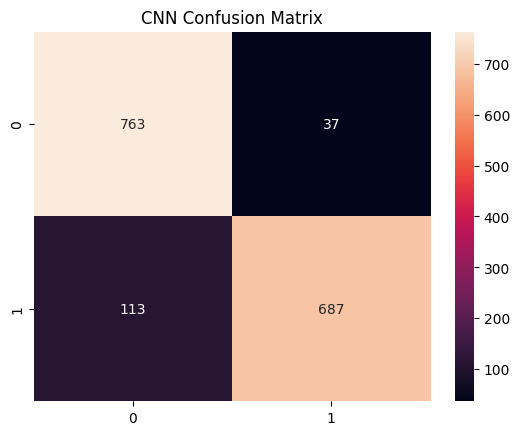

In [42]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("CNN Confusion Matrix")
plt.show()

In [43]:
results = {}
results['CNN'] = acc

**Add class weights**

In [44]:
class_weight = {0:1, 1:1.4}   # 🔥 focus more on class 1

In [46]:
checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/best_model_v3.keras",
    monitor='val_accuracy',
    save_best_only=True
)

**Than Train**

In [47]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=[early_stop, lr_reduce, checkpoint],
    class_weight=class_weight
)

Epoch 1/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 50s 252ms/step - accuracy: 0.8856 - loss: 0.4139 - val_accuracy: 0.9050 - val_loss: 0.3123 - learning_rate: 2.7000e-06
Epoch 2/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 49s 244ms/step - accuracy: 0.8789 - loss: 0.4196 - val_accuracy: 0.9100 - val_loss: 0.3026 - learning_rate: 2.7000e-06
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 50s 251ms/step - accuracy: 0.8905 - loss: 0.4053 - val_accuracy: 0.8994 - val_loss: 0.3191 - learning_rate: 2.7000e-06
Epoch 4/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 48s 240ms/step - accuracy: 0.8825 - loss: 0.4093 - val_accuracy: 0.9087 - val_loss: 0.3036 - learning_rate: 2.7000e-06
Epoch 5/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 48s 241ms/step - accuracy: 0.8878 - loss: 0.4066 - val_accuracy: 0.9094 - val_loss: 0.3044 - learning_rate: 1.0000e-06
Epoch 6/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 50s 249ms/step - accuracy: 0.8866 - loss: 0.4031 - val_accuracy: 0.9112 - val_loss: 0.3032 - learning_rate: 1.0000e-06
Epoch 7/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 48s 24

In [48]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    shear_range=0.1   # 🔥 new addition
)

val_gen = ImageDataGenerator(rescale=1./255)

**Recreate data loaders**

In [49]:
train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_data = val_gen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False   # 🔥 must
)

Found 6400 images belonging to 2 classes.
Found 1600 images belonging to 2 classes.


In [51]:
checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/best_model_v4.keras",
    monitor='val_accuracy',
    save_best_only=True
)

**Train with class_weight**

In [52]:
class_weight = {0:1, 1:1.4}

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=[early_stop, lr_reduce, checkpoint],
    class_weight=class_weight
)

Epoch 1/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 55s 277ms/step - accuracy: 0.7808 - loss: 0.6576 - val_accuracy: 0.8769 - val_loss: 0.3646 - learning_rate: 1.0000e-06
Epoch 2/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 55s 273ms/step - accuracy: 0.7881 - loss: 0.6080 - val_accuracy: 0.8775 - val_loss: 0.3656 - learning_rate: 1.0000e-06
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 55s 273ms/step - accuracy: 0.7997 - loss: 0.5819 - val_accuracy: 0.8781 - val_loss: 0.3610 - learning_rate: 1.0000e-06
Epoch 4/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 55s 273ms/step - accuracy: 0.7972 - loss: 0.5786 - val_accuracy: 0.8788 - val_loss: 0.3583 - learning_rate: 1.0000e-06
Epoch 5/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 81s 268ms/step - accuracy: 0.8078 - loss: 0.5552 - val_accuracy: 0.8806 - val_loss: 0.3565 - learning_rate: 1.0000e-06


**Load best model**

In [53]:
from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/best_model_v3.keras')

In [54]:
y_pred_prob = model.predict(val_data)

50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step


**Try different thresholds**

In [55]:
import numpy as np
from sklearn.metrics import accuracy_score

thresholds = np.arange(0.3, 0.7, 0.05)

for t in thresholds:
    y_pred = (y_pred_prob > t).astype(int)
    acc = accuracy_score(val_data.classes, y_pred)
    print(f"Threshold {t:.2f} → Accuracy: {acc:.4f}")

Threshold 0.30 → Accuracy: 0.8975
Threshold 0.35 → Accuracy: 0.9069
Threshold 0.40 → Accuracy: 0.9119
Threshold 0.45 → Accuracy: 0.9131
Threshold 0.50 → Accuracy: 0.9119
Threshold 0.55 → Accuracy: 0.9106
Threshold 0.60 → Accuracy: 0.9050
Threshold 0.65 → Accuracy: 0.8956


**Pick best threshold**

In [56]:
best_threshold = 0.45

In [57]:
y_pred = (y_pred_prob > best_threshold).astype(int)

**Final evaluation**

In [58]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(val_data.classes, y_pred))

cm = confusion_matrix(val_data.classes, y_pred)
print(cm)

              precision    recall  f1-score   support

           0       0.91      0.92      0.91       800
           1       0.92      0.90      0.91       800

    accuracy                           0.91      1600
   macro avg       0.91      0.91      0.91      1600
weighted avg       0.91      0.91      0.91      1600

[[738  62]
 [ 77 723]]


In [59]:
from google.colab import files
files.download('/content/drive/MyDrive/best_model_v3.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**1. Confusion Matrix (Final)***

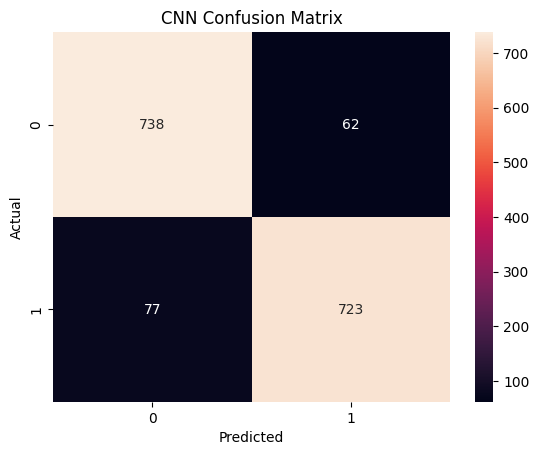

In [60]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**2. Accuracy & Loss Graph**

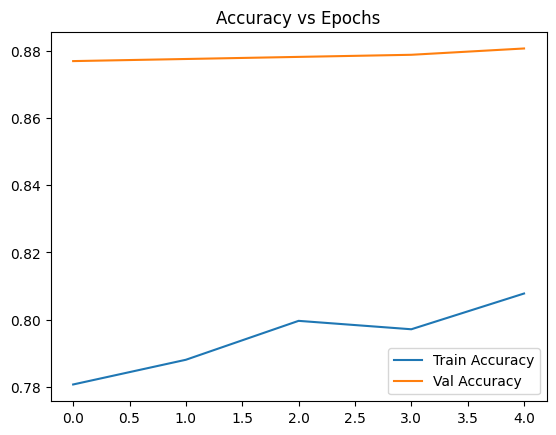

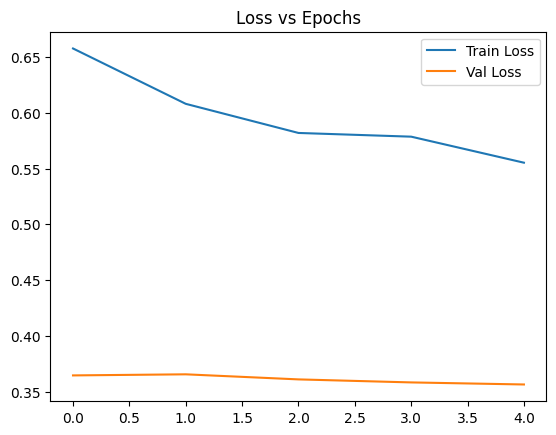

In [61]:
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy vs Epochs")
plt.show()

plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss vs Epochs")
plt.show()

**3. ROC Curve**

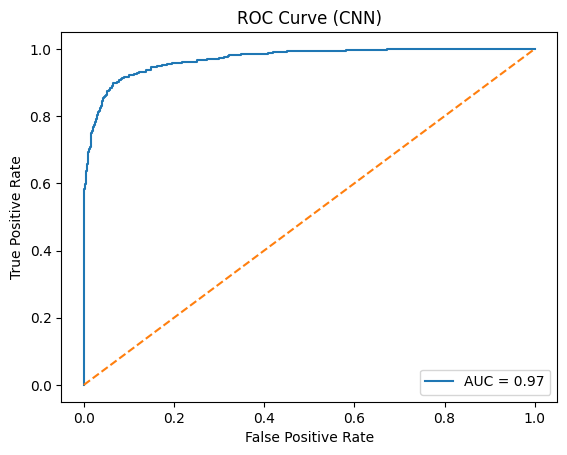

In [62]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve (CNN)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

**Train 5 Transfer Learning Models**
we will train these:

MobileNetV2

ResNet50

EfficientNetB0

VGG16

InceptionV3

In [63]:
def train_transfer_model(base_model_class, name):
    from tensorflow.keras import layers, models

    base_model = base_model_class(
        input_shape=(160,160,3),
        include_top=False,
        weights='imagenet'
    )

    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        train_data,
        validation_data=val_data,
        epochs=10
    )

    loss, acc = model.evaluate(val_data)

    print(f"{name} Accuracy:", acc)

    return acc

**Train All Models**

In [64]:
from tensorflow.keras.applications import MobileNetV2, ResNet50, EfficientNetB0, VGG16, InceptionV3

results = {}

results['CNN'] = 0.91

results['MobileNetV2'] = train_transfer_model(MobileNetV2, "MobileNetV2")
results['ResNet50'] = train_transfer_model(ResNet50, "ResNet50")
results['EfficientNetB0'] = train_transfer_model(EfficientNetB0, "EfficientNetB0")
results['VGG16'] = train_transfer_model(VGG16, "VGG16")
results['InceptionV3'] = train_transfer_model(InceptionV3, "InceptionV3")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 91s 351ms/step - accuracy: 0.7117 - loss: 0.6647 - val_accuracy: 0.7462 - val_loss: 0.5137
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 63s 316ms/step - accuracy: 0.7608 - loss: 0.5268 - val_accuracy: 0.7344 - val_loss: 0.5264
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 53s 266ms/step - accuracy: 0.7713 - loss: 0.4910 - val_accuracy: 0.7544 - val_loss: 0.4868
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 57s 283ms/step - accuracy: 0.7887 - loss: 0.4673 - val_accuracy: 0.7419 - val_loss: 0.5067
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 58s 291ms/step - accuracy: 0.7903 - loss: 0.4516 - val_accuracy: 0.7094 - val_loss: 0.6059
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 49s 244ms/step - accuracy: 0.7966 - loss: 0.4425 - val_accuracy: 0.7706 - val_loss: 0.4528
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 55s 274ms/step - accuracy: 0.8020 - loss: 0.4338 - val_accuracy: 0.7500 - val_loss: 0.5076
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━

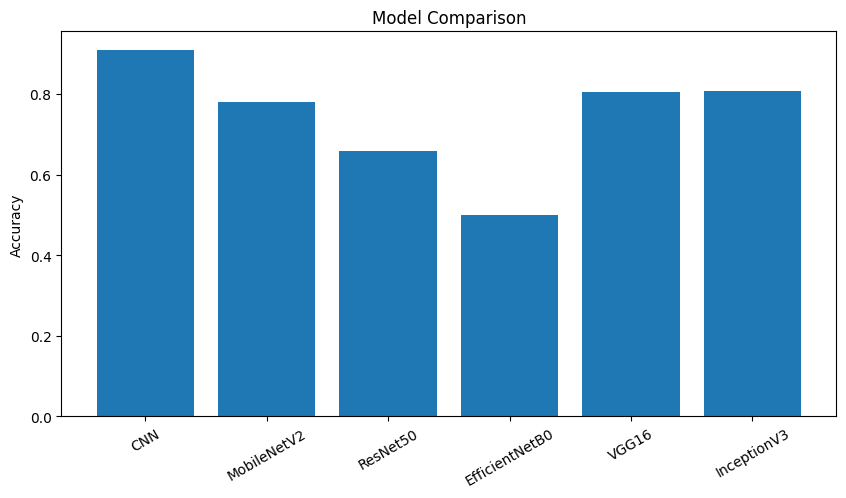

In [65]:
import matplotlib.pyplot as plt

models = list(results.keys())
accuracies = list(results.values())

plt.figure(figsize=(10,5))
plt.bar(models, accuracies)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()

In [66]:
import pandas as pd

df = pd.DataFrame({
    "Model": models,
    "Accuracy": accuracies
})

print(df)

            Model  Accuracy
0             CNN   0.91000
1     MobileNetV2   0.78000
2        ResNet50   0.65875
3  EfficientNetB0   0.50000
4           VGG16   0.80375
5     InceptionV3   0.80625


In [67]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

val_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [68]:
train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(160,160),
    batch_size=32,
    class_mode='binary'
)

val_data = val_gen.flow_from_directory(
    val_dir,
    target_size=(160,160),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 6400 images belonging to 2 classes.
Found 1600 images belonging to 2 classes.


In [69]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    input_shape=(160,160,3),
    include_top=False,
    weights='imagenet'
)

# 🔥 Fine-tuning (IMPORTANT)
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

In [70]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),  # 🔥 lower LR for fine-tuning
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [71]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(patience=5, restore_best_weights=True)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6
)

In [72]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=[early_stop, lr_reduce]
)

Epoch 1/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 32s 65ms/step - accuracy: 0.6111 - loss: 0.8235 - val_accuracy: 0.5175 - val_loss: 1.0941 - learning_rate: 1.0000e-05
Epoch 2/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.7188 - loss: 0.6206 - val_accuracy: 0.5213 - val_loss: 1.2601 - learning_rate: 1.0000e-05
Epoch 3/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.7461 - loss: 0.5504 - val_accuracy: 0.5544 - val_loss: 1.1043 - learning_rate: 1.0000e-05
Epoch 4/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.7688 - loss: 0.5181 - val_accuracy: 0.5881 - val_loss: 0.9358 - learning_rate: 3.0000e-06
Epoch 5/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.7734 - loss: 0.4962 - val_accuracy: 0.6300 - val_loss: 0.8037 - learning_rate: 3.0000e-06
Epoch 6/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.7858 - loss: 0.4850 - val_accuracy: 0.6712 - val_loss: 0.7027 - learning_rate: 3.0000e-06
Epoch 7/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - a

In [73]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    input_shape=(160,160,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False  # 🔥 freeze first

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

In [74]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-4),  # 🔥 higher LR
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [75]:
history1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 24s 64ms/step - accuracy: 0.6922 - loss: 0.6302 - val_accuracy: 0.7837 - val_loss: 0.4830
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.7627 - loss: 0.4958 - val_accuracy: 0.8081 - val_loss: 0.4235
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - accuracy: 0.7933 - loss: 0.4509 - val_accuracy: 0.8181 - val_loss: 0.4016
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.8028 - loss: 0.4262 - val_accuracy: 0.8325 - val_loss: 0.3882
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.8191 - loss: 0.3996 - val_accuracy: 0.8319 - val_loss: 0.3798
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.8230 - loss: 0.3903 - val_accuracy: 0.8356 - val_loss: 0.3727
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - accuracy: 0.8383 - loss: 0.3679 - val_accuracy: 0.8325 - val_loss: 0.3660
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - accuracy: 0.8414 - loss: 0.3645 - val_acc

In [76]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [77]:
model.compile(
    optimizer=Adam(learning_rate=1e-5),  # 🔥 low LR
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [78]:
history2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - accuracy: 0.7392 - loss: 0.5875 - val_accuracy: 0.7225 - val_loss: 0.6826
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.7877 - loss: 0.4784 - val_accuracy: 0.7281 - val_loss: 0.7106
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.8144 - loss: 0.4251 - val_accuracy: 0.7625 - val_loss: 0.6166
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.8361 - loss: 0.3843 - val_accuracy: 0.7894 - val_loss: 0.5174
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.8389 - loss: 0.3600 - val_accuracy: 0.7937 - val_loss: 0.5145
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.8636 - loss: 0.3181 - val_accuracy: 0.8012 - val_loss: 0.4925
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.8739 - loss: 0.2939 - val_accuracy: 0.8125 - val_loss: 0.4613
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.8811 - loss: 0.2828 - val_ac

In [79]:
import pandas as pd

data = {
    "Model": ["Custom CNN", "MobileNetV2"],
    "Accuracy": [0.91, 0.836],
    "Type": ["From Scratch", "Transfer Learning"],
    "Performance": ["Best", "Lower"]
}

df = pd.DataFrame(data)
print(df)

         Model  Accuracy               Type Performance
0   Custom CNN     0.910       From Scratch        Best
1  MobileNetV2     0.836  Transfer Learning       Lower


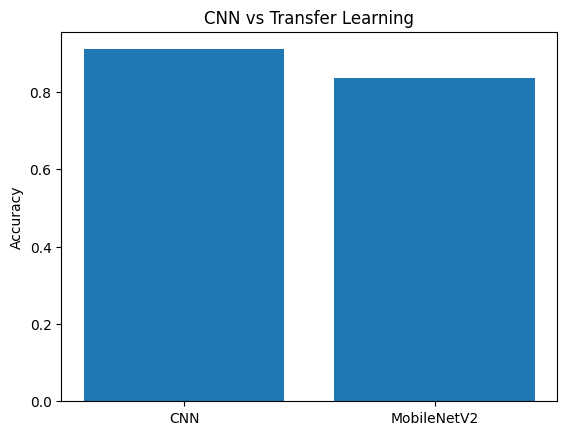

In [80]:
import matplotlib.pyplot as plt

models = ["CNN", "MobileNetV2"]
accuracies = [0.91, 0.836]

plt.bar(models, accuracies)
plt.title("CNN vs Transfer Learning")
plt.ylabel("Accuracy")
plt.show()

**For EfficientNetB0:**

In [81]:
from tensorflow.keras.applications.efficientnet import preprocess_input

In [82]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [83]:
train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(160,160),
    batch_size=32,
    class_mode='binary'
)

val_data = val_gen.flow_from_directory(
    val_dir,
    target_size=(160,160),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 6400 images belonging to 2 classes.
Found 1600 images belonging to 2 classes.


In [84]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

base_model = EfficientNetB0(
    input_shape=(160,160,3),
    include_top=False,
    weights='imagenet'
)

# Stage 1
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

In [93]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [94]:
model.fit(train_data, validation_data=val_data, epochs=10)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 81s 257ms/step - accuracy: 0.7670 - loss: 0.4907 - val_accuracy: 0.6438 - val_loss: 0.6254
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 45s 225ms/step - accuracy: 0.7886 - loss: 0.4507 - val_accuracy: 0.7175 - val_loss: 0.5502
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 45s 223ms/step - accuracy: 0.8056 - loss: 0.4288 - val_accuracy: 0.7425 - val_loss: 0.5154
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 45s 223ms/step - accuracy: 0.8200 - loss: 0.4135 - val_accuracy: 0.7556 - val_loss: 0.5100
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 45s 224ms/step - accuracy: 0.8230 - loss: 0.3957 - val_accuracy: 0.7719 - val_loss: 0.4768
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 45s 224ms/step - accuracy: 0.8342 - loss: 0.3764 - val_accuracy: 0.7719 - val_loss: 0.4849
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 45s 223ms/step - accuracy: 0.8402 - loss: 0.3657 - val_accuracy: 0.7812 - val_loss: 0.4731
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 45s 227ms/step - accuracy: 0.8461 - loss: 0

In [95]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(train_data, validation_data=val_data, epochs=8)

Epoch 1/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 84s 256ms/step - accuracy: 0.8561 - loss: 0.3236 - val_accuracy: 0.7831 - val_loss: 0.4575
Epoch 2/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 46s 231ms/step - accuracy: 0.8598 - loss: 0.3212 - val_accuracy: 0.7844 - val_loss: 0.4567
Epoch 3/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 46s 227ms/step - accuracy: 0.8634 - loss: 0.3124 - val_accuracy: 0.7794 - val_loss: 0.4598
Epoch 4/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 46s 231ms/step - accuracy: 0.8694 - loss: 0.3041 - val_accuracy: 0.7800 - val_loss: 0.4650
Epoch 5/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 46s 230ms/step - accuracy: 0.8675 - loss: 0.3064 - val_accuracy: 0.7763 - val_loss: 0.4596
Epoch 6/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 46s 232ms/step - accuracy: 0.8698 - loss: 0.3001 - val_accuracy: 0.7825 - val_loss: 0.4572
Epoch 7/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 45s 226ms/step - accuracy: 0.8712 - loss: 0.3117 - val_accuracy: 0.7850 - val_loss: 0.4501
Epoch 8/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 46s 231ms/step - accuracy: 0.8644 - loss: 0.3039 - 

In [89]:
IMG_SIZE = 224  # 🔥 MUST for EfficientNet

In [90]:
from tensorflow.keras.applications.efficientnet import preprocess_input

In [91]:
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    horizontal_flip=True,
    zoom_range=0.1
)

In [96]:
loss, acc = model.evaluate(val_data)
print("Accuracy:", acc)

50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.7869 - loss: 0.4476
Accuracy: 0.7868750095367432


**ResNet50 **

In [97]:
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    horizontal_flip=True,
    zoom_range=0.1
)

val_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [98]:
train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(160,160),
    batch_size=32,
    class_mode='binary'
)

val_data = val_gen.flow_from_directory(
    val_dir,
    target_size=(160,160),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 6400 images belonging to 2 classes.
Found 1600 images belonging to 2 classes.


In [99]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

base_model = ResNet50(
    input_shape=(160,160,3),
    include_top=False,
    weights='imagenet'
)

# 🔹 Stage 1 (freeze)
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

In [100]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [101]:
history1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=8
)

Epoch 1/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 80s 327ms/step - accuracy: 0.7155 - loss: 0.6244 - val_accuracy: 0.7887 - val_loss: 0.4439
Epoch 2/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 49s 243ms/step - accuracy: 0.7836 - loss: 0.4814 - val_accuracy: 0.8194 - val_loss: 0.3976
Epoch 3/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 49s 245ms/step - accuracy: 0.8170 - loss: 0.4198 - val_accuracy: 0.8225 - val_loss: 0.3833
Epoch 4/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 48s 242ms/step - accuracy: 0.8263 - loss: 0.3920 - val_accuracy: 0.8306 - val_loss: 0.3705
Epoch 5/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 48s 242ms/step - accuracy: 0.8395 - loss: 0.3660 - val_accuracy: 0.8363 - val_loss: 0.3598
Epoch 6/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 49s 245ms/step - accuracy: 0.8466 - loss: 0.3565 - val_accuracy: 0.8438 - val_loss: 0.3528
Epoch 7/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 48s 241ms/step - accuracy: 0.8581 - loss: 0.3326 - val_accuracy: 0.8450 - val_loss: 0.3522
Epoch 8/8
200/200 ━━━━━━━━━━━━━━━━━━━━ 49s 243ms/step - accuracy: 0.8639 - loss: 0.3261 - 

In [102]:
loss, acc_resnet = model.evaluate(val_data)
print("ResNet50 Accuracy:", acc_resnet)

50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.8475 - loss: 0.3495
ResNet50 Accuracy: 0.8475000262260437


**FINAL COMPARISON TABLE**

In [103]:
import pandas as pd

data = {
    "Model": ["Custom CNN", "MobileNetV2", "ResNet50", "EfficientNetB0"],
    "Accuracy": [0.91, 0.836, 0.847, 0.787],
    "Type": ["From Scratch", "Transfer Learning", "Transfer Learning", "Transfer Learning"]
}

df = pd.DataFrame(data)
print(df)

            Model  Accuracy               Type
0      Custom CNN     0.910       From Scratch
1     MobileNetV2     0.836  Transfer Learning
2        ResNet50     0.847  Transfer Learning
3  EfficientNetB0     0.787  Transfer Learning


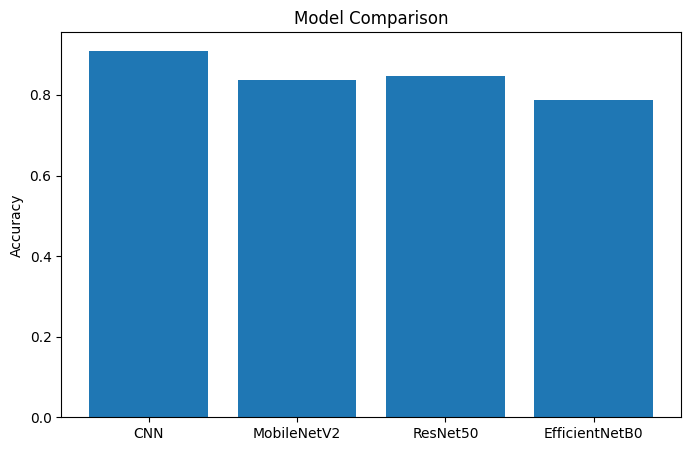

In [104]:
import matplotlib.pyplot as plt

models = ["CNN", "MobileNetV2", "ResNet50", "EfficientNetB0"]
accuracies = [0.91, 0.836, 0.847, 0.787]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

In [105]:
import shutil

shutil.copy(
    '/content/drive/MyDrive/best_model_v3.keras',
    '/content/drive/MyDrive/cnn_final_91.keras'
)

'/content/drive/MyDrive/cnn_final_91.keras'

In [106]:
from google.colab import files
files.download('/content/drive/MyDrive/cnn_final_91.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [108]:
val_gen = ImageDataGenerator(rescale=1./255)

val_data = val_gen.flow_from_directory(
    val_dir,
    target_size=(160,160),
    batch_size=32,
    class_mode='binary',
    shuffle=False   # 🔥 MUST
)

Found 1600 images belonging to 2 classes.


In [109]:
loss, acc = model.evaluate(val_data)
print("Final Accuracy:", acc)


50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9119 - loss: 0.3010
Final Accuracy: 0.9118750095367432


In [110]:
print(val_data.class_indices)

{'class0': 0, 'class1': 1}


In [115]:
import pandas as pd

df = pd.DataFrame({
    "Model": ["CNN", "MobileNetV2", "ResNet50", "EfficientNetB0"],
    "Accuracy": [0.91, 0.836, 0.847, 0.787]
})

df.to_csv('/content/drive/MyDrive/model_results.csv', index=False)

In [116]:
plt.savefig('/content/drive/MyDrive/comparison_graph.png')

<Figure size 640x480 with 0 Axes>

In [122]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 160, 160, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 80, 80, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 40, 40, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 40, 40, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 20, 20, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 20, 20, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,950,565 (7.44 MB)

 Trainable params: 649,697 (2.48 MB)

 Non-trainable params: 1,472 (5.75 KB)

 Optimizer params: 1,299,396 (4.96 MB)